# Classification: The Logistic regression Model - Logit

In [68]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [69]:
df = pd.read_csv("Default.csv")
display(df.head(10))
display(df.shape)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
5,No,Yes,919.588530,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451344
8,No,No,1161.057854,37468.529288
9,No,No,0.000000,29275.268293


(10000, 4)

In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
balance,10000.0,835.374886,483.714985,0.000000,481.731105,823.636973,1166.308386,2654.322576
income,10000.0,33516.981876,13336.639563,771.967729,21340.462903,34552.644802,43807.729272,73554.233495
default_binary,10000.0,0.033300,0.179428,0.000000,0.000000,0.000000,0.000000,1.000000


## Graphical Exploratory Data Analysis (EDA)

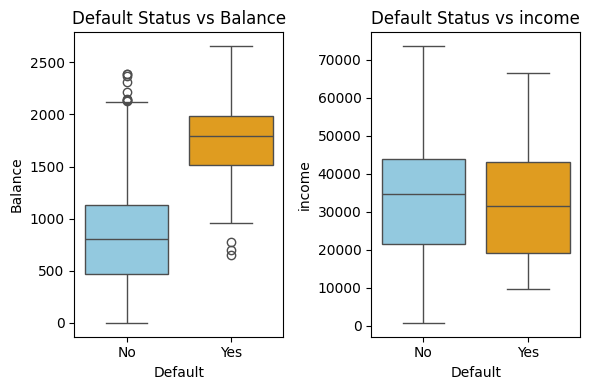

In [70]:
import warnings
warnings.filterwarnings('ignore')

fig, ax = plt.subplots(1, 2, figsize=(6, 4))

sns.boxplot(x='default', y='balance', data=df, palette={'No': 'skyblue', 'Yes': 'orange'},ax=ax[0])
ax[0].set_title('Default Status vs Balance')
ax[0].set_xlabel('Default')
ax[0].set_ylabel('Balance')

sns.boxplot(x='default', y='income', data=df, palette={'No': 'skyblue', 'Yes': 'orange'},ax=ax[1])
ax[1].set_title('Default Status vs income')
ax[1].set_xlabel('Default')
ax[1].set_ylabel('income')

plt.tight_layout()
plt.show()

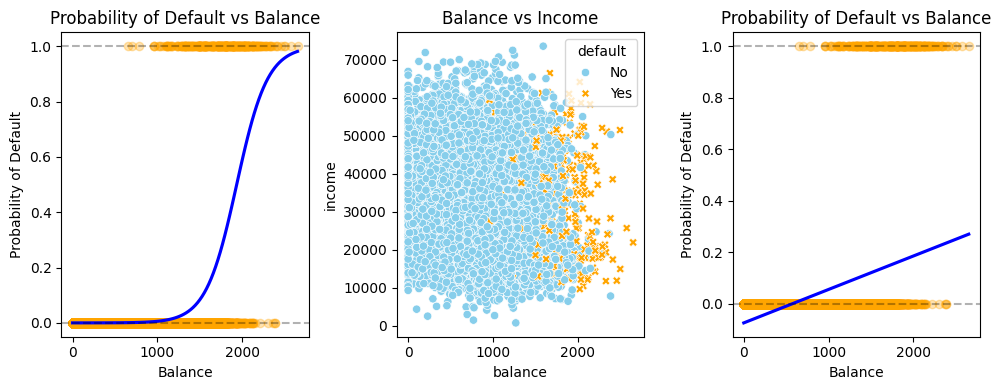

In [71]:
# Convert 'default' to binary for the math
df['default_binary'] = df['default'].map({'No': 0, 'Yes': 1})

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

#Plot 1:
# sns.regplot with logistic=True handles the S-curve calculation for you
sns.regplot(x='balance', y='default_binary', data=df, 
            logistic=True, ci=None,
            scatter_kws={'color': 'orange', 'alpha': 0.3}, 
            line_kws={'color': 'blue'}, ax=ax[0])
# Add horizontal dashed lines for probability markers 0 and 1
ax[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax[0].axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax[0].set_title('Probability of Default vs Balance')
ax[0].set_xlabel('Balance')
ax[0].set_ylabel('Probability of Default')

# Plot 2: Scatter plot
# We use 'edgecolors' to make the dots look like the "rings" in the ISLP book
sns.scatterplot(x='balance', y='income', hue='default', data=df, 
                palette={'No': 'skyblue', 'Yes': 'orange'}, 
                style='default', ax=ax[1])
ax[1].set_title('Balance vs Income')

#Plot 3:
# sns.regplot with logistic=False - Linear Regression
sns.regplot(x='balance', y='default_binary', data=df, 
            logistic=False, ci=None,
            scatter_kws={'color': 'orange', 'alpha': 0.3}, 
            line_kws={'color': 'blue'}, ax=ax[2])
# Add horizontal dashed lines for probability markers 0 and 1
ax[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax[2].axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax[2].set_title('Probability of Default vs Balance')
ax[2].set_xlabel('Balance')
ax[2].set_ylabel('Probability of Default')

plt.tight_layout()
plt.show()

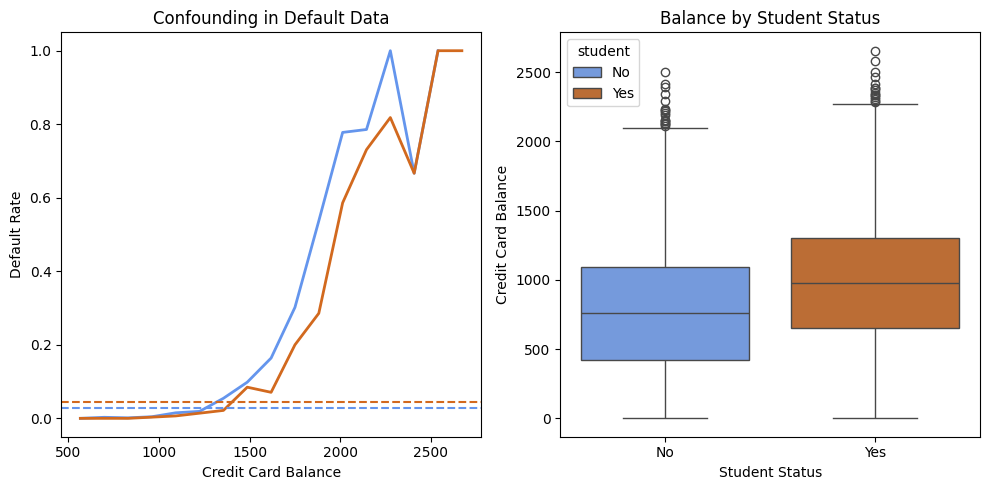

In [81]:
# 1. Load the Default dataset 
default_df = pd.read_csv("Default.csv") 

# Set up the figure with two subplots 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

# --- LEFT PLOT: Default Rate vs Balance (Confounding) --- 
# We need to bin the balance to show a "rate" or use a smoothing function 
# For a quick recreation, we'll calculate the mean default for balance bins 
default_df['default_bin'] = (default_df['default'] == 'Yes').astype(int) 
default_df['balance_group'] = pd.cut(default_df['balance'], bins=np.linspace(500, 3000, 20)) 

# Calculate rates per group for students vs non-students 
rates = default_df.groupby(['balance_group', 'student'], observed=False)['default_bin'].mean().unstack() 
bin_centers = [bin.mid for bin in rates.index] 

# Plot solid lines 
ax1.plot(bin_centers, rates['No'], color='cornflowerblue', label='Non-Student', lw=2) 
ax1.plot(bin_centers, rates['Yes'], color='chocolate', label='Student', lw=2) 
# Plot horizontal dashed lines (overall rates) 
overall_non_student = default_df[default_df['student'] == 'No']['default_bin'].mean() 
overall_student = default_df[default_df['student'] == 'Yes']['default_bin'].mean() 
ax1.axhline(overall_non_student, color='cornflowerblue', linestyle='--') 
ax1.axhline(overall_student, color='chocolate', linestyle='--') 
ax1.set_xlabel('Credit Card Balance') 
ax1.set_ylabel('Default Rate') 
ax1.set_title('Confounding in Default Data') 

# --- RIGHT PLOT: Boxplots of Balance --- 
sns.boxplot(x='student', y='balance', data=default_df, palette={'No': 'cornflowerblue', 'Yes': 'chocolate'}, 
            hue='student', legend=True, ax=ax2) 
ax2.set_xlabel('Student Status') 
ax2.set_ylabel('Credit Card Balance') 
ax2.set_xticklabels(['No', 'Yes']) 
ax2.set_title('Balance by Student Status') 

plt.tight_layout() 
plt.show()  

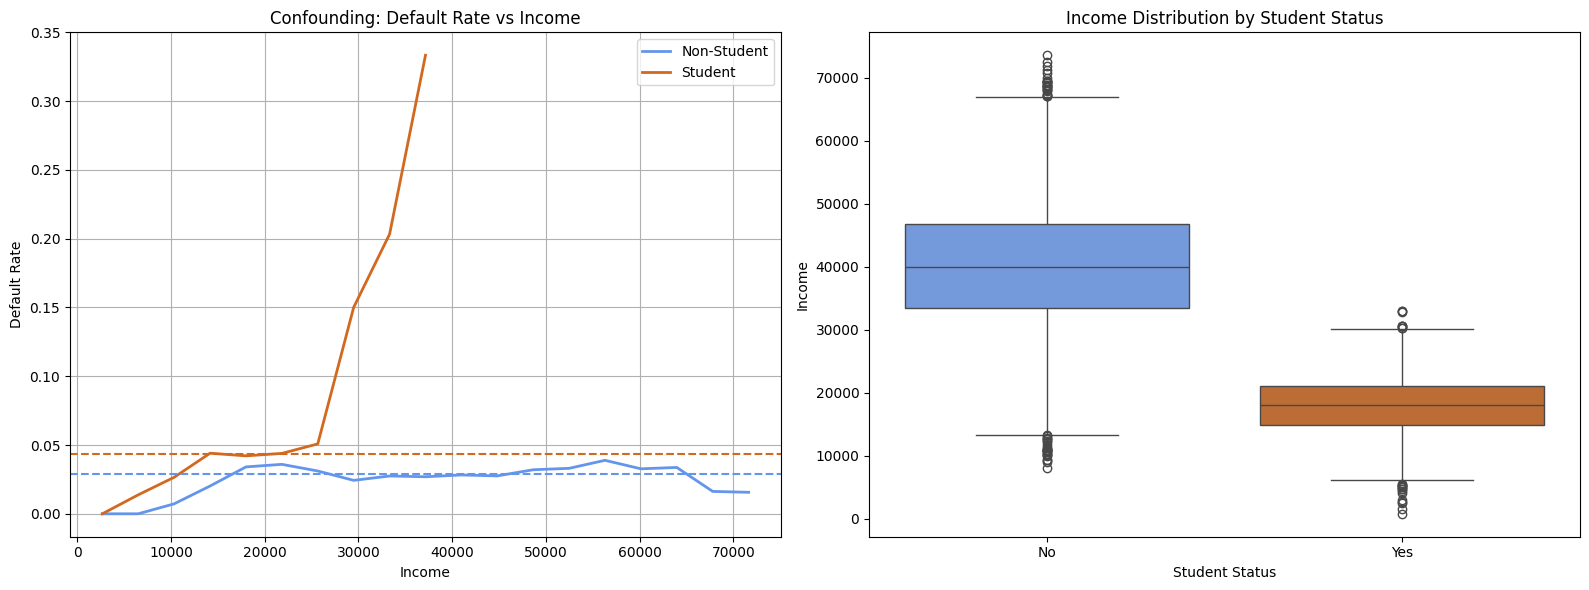

In [85]:
# Copy of dataframe to avoid modifying original
df_plot = default_df.copy()

# Convert 'default' to numeric for rate calculation
df_plot['default_bin'] = (df_plot['default'] == 'Yes').astype(int)

# --- LEFT PLOT: Default Rate vs Income (Confounding) ---
# Bin income into 20 groups
income_bins = np.linspace(df_plot['income'].min(), df_plot['income'].max(), 20)
df_plot['income_group'] = pd.cut(df_plot['income'], bins=income_bins)

# Calculate mean default rate per income bin, separate by student status
rates = df_plot.groupby(['income_group', 'student'], observed=False)['default_bin'].mean().unstack()

# Compute bin centers for plotting
bin_centers = [bin.mid for bin in rates.index]

# Optional smoothing
rates_smooth = rates.rolling(window=3, center=True, min_periods=1).mean()

# --- Create figure with two subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# LEFT: Line plot (Default Rate vs Income)
ax1.plot(bin_centers, rates_smooth['No'], color='cornflowerblue', label='Non-Student', lw=2)
ax1.plot(bin_centers, rates_smooth['Yes'], color='chocolate', label='Student', lw=2)

# Horizontal dashed lines for overall default rates
overall_non_student = df_plot[df_plot['student'] == 'No']['default_bin'].mean()
overall_student = df_plot[df_plot['student'] == 'Yes']['default_bin'].mean()
ax1.axhline(overall_non_student, color='cornflowerblue', linestyle='--')
ax1.axhline(overall_student, color='chocolate', linestyle='--')

ax1.set_xlabel('Income')
ax1.set_ylabel('Default Rate')
ax1.set_title('Confounding: Default Rate vs Income')
ax1.legend()
ax1.grid(True)

# --- RIGHT: Boxplot of Income by Student Status ---
sns.boxplot(x='student', y='income', data=df_plot,
            palette={'No': 'cornflowerblue', 'Yes': 'chocolate'},
            ax=ax2)
ax2.set_xlabel('Student Status')
ax2.set_ylabel('Income')
ax2.set_xticklabels(['No', 'Yes'])
ax2.set_title('Income Distribution by Student Status')

plt.tight_layout()
plt.show()

## Model EDA

In [46]:
df['default'].value_counts(normalize=True)

default
No     0.9667
Yes    0.0333
Name: proportion, dtype: float64

In [47]:
pd.crosstab(df['student'], df['default'], normalize='index')

default,No,Yes
student,,
No,0.970805,0.029195
Yes,0.956861,0.043139


In [48]:
df[['balance', 'income']].corr()

,balance,income
balance,1.000000,-0.152243
income,-0.152243,1.000000


## Model Fit

### Training the Model(s)

In [87]:
# Convert categorical variables to numeric (required for regression)
# default: Yes → 1, No → 0
# student: Yes → 1, No → 0
df['default'] = (df['default'] == 'Yes').astype(int)
df['student'] = (df['student'] == 'Yes').astype(int)

# Check transformation
display(df.head())

,default,student,balance,income,default_binary
0,0,0,729.526495,44361.625074,0
1,0,1,817.180407,12106.134700,0
2,0,0,1073.549164,31767.138947,0
3,0,0,529.250605,35704.493935,0
4,0,0,785.655883,38463.495879,0


### 0. Partial Model 0 — Income Only (Not Significant)

In [88]:
# Define predictor matrix (ONLY balance)
X_income = df[['income']]

# Add intercept (β0)
X_income = sm.add_constant(X_income)

# Define response variable
y = df['default']

# Fit logistic regression model
model_income = sm.Logit(y, X_income)
result_income = model_income.fit()

# Display results
display(result_income.summary())

Optimization terminated successfully.
         Current function value: 0.145834
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                0.001357
Time:                        14:44:20   Log-Likelihood:                -1458.3
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                   0.04652
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0941      0.146    -21.156      0.000      -3.381      -2.807
income     -8.353e-06   4.21e-06     -1.985      0.047   -1.66e-05   -1.06e-07
==============================================================================
"""

### 1. Partial Model 1 — Balance Only
 - Objective: Estimate the effect of balance alone on default probability.

In [50]:
# Define predictor matrix (ONLY balance)
X_balance = df[['balance']]

# Add intercept (β0)
X_balance = sm.add_constant(X_balance)

# Define response variable
y = df['default']

# Fit logistic regression model
model_balance = sm.Logit(y, X_balance)
result_balance = model_balance.fit()

# Display results
display(result_balance.summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.4534
Time:                        13:38:44   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0.000     24.952      0.000       0.005       0.006
==============================================================================

Possibly complete quasi-separation: A fraction 0.13 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

### 2. Partial Model 2 — Student Only
- Objective: Estimate the effect of student status alone.

In [51]:
# Define predictor matrix (ONLY student)
X_student = df[['student']]

# Add intercept
X_student = sm.add_constant(X_student)

# Fit logistic regression
model_student = sm.Logit(y, X_student)
result_student = model_student.fit()

# Display results
display(result_student.summary())

Optimization terminated successfully.
         Current function value: 0.145434
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                0.004097
Time:                        13:38:47   Log-Likelihood:                -1454.3
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                 0.0005416
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5041      0.071    -49.554      0.000      -3.643      -3.366
student        0.4049      0.115      3.520      0.000       0.179       0.630
==============================================================================
"""

### 3. Full Model — Balance + Income + Student
- Objective: Estimate conditional effects (this is the key ISLP step)

In [52]:
# Define full predictor set
X_full = df[['balance', 'income', 'student']]

# Add intercept
X_full = sm.add_constant(X_full)

# Fit logistic regression
model_full = sm.Logit(y, X_full)
result_full = model_full.fit()

# Display results
display(result_full.summary())

Optimization terminated successfully.
         Current function value: 0.078577
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.4619
Time:                        13:38:48   Log-Likelihood:                -785.77
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                3.257e-292
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8690      0.492    -22.079      0.000     -11.834      -9.904
balance        0.0057      0.000     24.737      0.000       0.005       0.006
income      3.033e-06    8.2e-06      0.370      0.712    -1.3e-05    1.91e-05
student       -0.6468      0.236     -2.738      0.006      -1.110      -0.184
==============================================================================

Possibly complete quasi-separation: A fraction 0.15 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

### Annex 1 - Logistic Regression Analysis Explained

#### Overview
We estimated three logistic regression models to understand the relationship between **default** and the predictors:
- `balance`
- `income`
- `student`

The goal is to distinguish between **marginal** and **conditional** effects.

---

#### Model 1: `default ~ balance`

##### Key Results:
- Coefficient (balance): **+0.0055** (p < 0.001)
- Pseudo R²: **0.453**
- Log-Likelihood: **−798**

##### Interpretation:
- Balance has a **strong positive effect** on default probability.
- Each $1 increase in balance increases the odds of default by ~0.55%.
- Over larger amounts (e.g., $1000), this effect becomes substantial.

##### Conclusion:
> Balance is a **very strong predictor** of default on its own.

---

#### Model 2: `default ~ student`

##### Key Results:
- Coefficient (student): **+0.405** (p < 0.001)
- Pseudo R²: **0.004**
- Log-Likelihood: **−1454**

##### Interpretation:
- Students appear to have **higher default risk**.
- Odds ratio ≈ 1.50 → students have ~50% higher odds of default.

##### Limitation:
- This is a **marginal relationship** (does not control for other variables).

#### Conclusion:
> Student status alone has **very weak explanatory power**.

---

#### Model 3: `default ~ balance + income + student`

##### Key Results:
- Balance: **+0.0057** (p < 0.001)
- Income: **not significant** (p = 0.712)
- Student: **−0.647** (p = 0.006)
- Pseudo R²: **0.462**
- Log-Likelihood: **−786**

##### Interpretation:

Balance:
- Remains **strongly positive and highly significant**
- Dominant predictor of default risk

Income:
- No statistically significant effect
- Adds little information once balance is included

Student (Critical Insight):
- Coefficient becomes **negative**
- Odds ratio ≈ 0.52 → students have ~48% lower odds of default *conditional on balance*

---

#### Confounding Effect

- In Model 2, students appear riskier because they tend to have **higher balances**
- Balance strongly increases default probability
- Once we control for balance (Model 3), the relationship reverses

##### Conclusion:
> The positive relationship between student status and default is **confounded by balance**

---

#### Model Comparison

| Model | Log-Likelihood | Pseudo R² |
|------|--------------|----------|
| Balance only | −798 | 0.453 |
| Student only | −1454 | 0.004 |
| Full model | **−786** | **0.462** |

## Model 3 Interpretations

- Convert Coefficients → Odds Ratios
- Logistic regression coefficients are in log-odds units, which are not intuitive.
- We exponentiate them to get odds ratios.

In [53]:
# Extract coefficients
coefficients = result_full.params

# Convert to odds ratios
odds_ratios = np.exp(coefficients)

# Display neatly
odds_df = pd.DataFrame({
    "Coefficient (log-odds)": coefficients,
    "Odds Ratio": odds_ratios
})

display(odds_df)

,Coefficient (log-odds),Odds Ratio
const,-10.869045,0.000019
balance,0.005737,1.005753
income,0.000003,1.000003
student,-0.646776,0.523732


#### Why Odds Ratios Are Useful

Odds ratios provide a more interpretable way to understand logistic regression coefficients by translating log-odds into **multiplicative effects on the odds**.

##### Scale-Invariant Interpretation
- Effects are **multiplicative**, not additive
- This makes them consistent across different units and scales
- Easier to compare the relative importance of predictors

##### Direction of Effect
- Odds Ratio > 1 → **Increases** the odds of the event (higher risk)
- Odds Ratio < 1 → **Decreases** the odds of the event (lower risk)
- Odds Ratio = 1 → **No effect** on the odds

---

#### Interpretation of Your Model

| Variable | Odds Ratio | Interpretation |
|---------|-----------|----------------|
| balance | 1.005753 | Each +1 unit increases odds by ~0.575% |
| income  | 1.000003 | No meaningful effect |
| student | 0.523732 | Students have ~48% lower odds (holding others fixed) |


## Model 3 Predictions

- Objective: Compute estimated probability of default for each observation

In [58]:
probs = result_full.predict(X_full)

# Convert probabilities to binary predictions
predictions = (probs > 0.5).astype(int)

# Compare first few predictions with actual values
comparison = pd.DataFrame({
    "Actual": y,
    "Predicted": predictions,
    "Probability": probs
})

display(comparison.head())

,Actual,Predicted,Probability
0,0,0,0.001429
1,0,0,0.001122
2,0,0,0.009812
3,0,0,0.000442
4,0,0,0.001936


## Model 3 Evaluation

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Recall,F1 Score
0,0.01,7163,2504,12,321,0.7484,0.113628,0.963964,0.203293
1,0.02,7929,1738,26,307,0.8236,0.150122,0.921922,0.258200
2,0.03,8290,1377,32,301,0.8591,0.179380,0.903904,0.299354
3,0.04,8521,1146,44,289,0.8810,0.201394,0.867868,0.326923
4,0.05,8702,965,52,281,0.8983,0.225522,0.843844,0.355921
5,0.06,8829,838,64,269,0.9098,0.242999,0.807808,0.373611
6,0.07,8924,743,71,262,0.9186,0.260697,0.786787,0.391629
7,0.08,8989,678,78,255,0.9244,0.273312,0.765766,0.402844
8,0.09,9055,612,80,253,0.9308,0.292486,0.759760,0.422371
9,0.10,9107,560,85,248,0.9355,0.306931,0.744745,0.434706


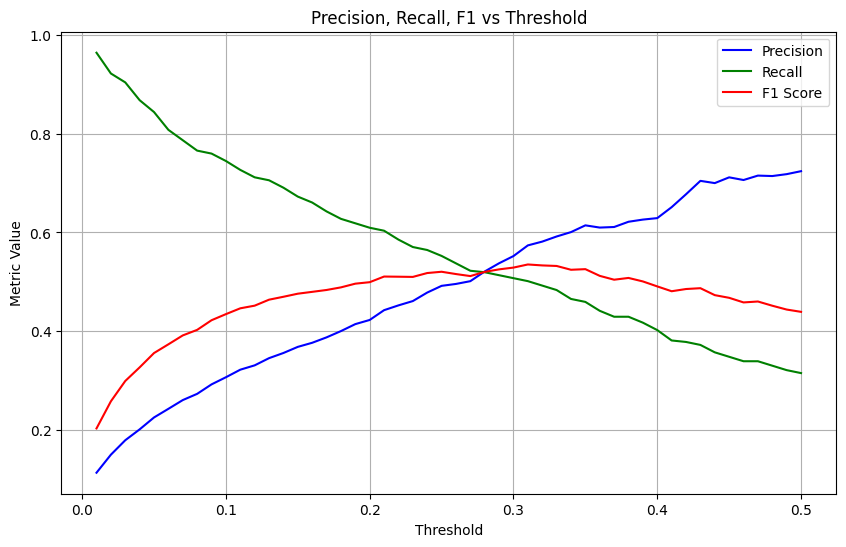

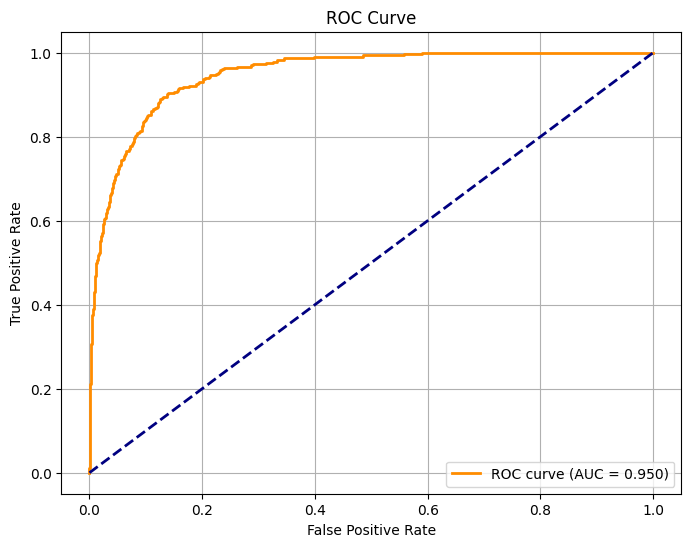

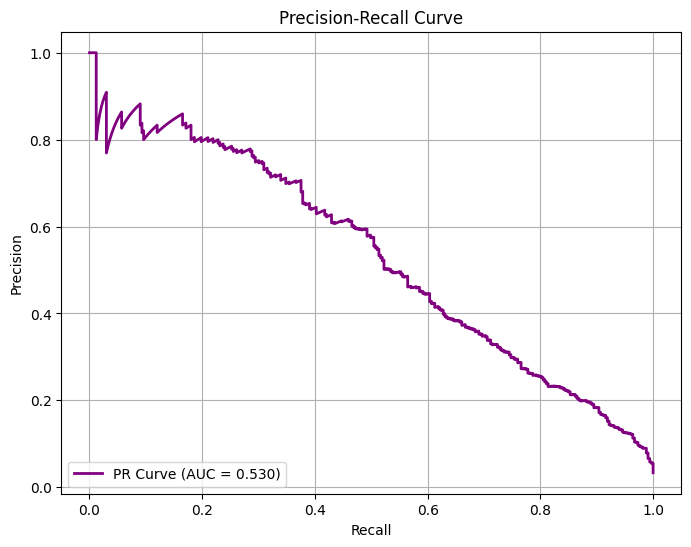

In [61]:
# 🔹 Comprehensive Evaluation for Logistic Regression (Default dataset)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

def evaluate_thresholds(y_true, y_probs, thresholds=np.arange(0.01, 0.51, 0.01)):
    """
    Evaluate logistic regression predictions across multiple thresholds.
    
    Returns a DataFrame with metrics for each threshold.
    """
    results = []
    
    for t in thresholds:
        y_pred = (y_probs > t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        accuracy  = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall    = recall_score(y_true, y_pred, zero_division=0)
        f1        = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            "Threshold": t,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })
    
    return pd.DataFrame(results)

# Example usage: evaluate all thresholds from 0.01 to 0.5
metrics_df = evaluate_thresholds(y, probs)
display(metrics_df.head(10))  # inspect first few thresholds

# 🔹 Plot Precision, Recall, F1 vs Threshold
plt.figure(figsize=(10,6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], label='F1 Score', color='red')
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# 🔹 ROC Curve and AUC
fpr, tpr, roc_thresholds = roc_curve(y, probs)
roc_auc = roc_auc_score(y, probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 🔹 Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, probs)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

## Annex 2 - Model Evanluation and Confusion Matrix
### 1. Structure of the Table

Each row corresponds to a **different threshold** (0.01 → 0.10 here).

| Column | Meaning |
| --- | --- |
| Threshold | The cutoff probability used to classify a default (1) |
| TN | True Negatives — correctly predicted non-defaults |
| FP | False Positives — predicted default but actually no default |
| FN | False Negatives — missed defaults |
| TP | True Positives — correctly predicted defaults |
| Accuracy | (TN + TP)/Total — overall fraction correct |
| Precision | TP / (TP + FP) — fraction of predicted defaults that were correct |
| Recall | TP / (TP + FN) — fraction of actual defaults detected |
| F1 Score | Harmonic mean of Precision & Recall — balances them |

---

### 2. Key Patterns Across Thresholds

**TN vs FP**
- As threshold **increases**, TN ↑, FP ↓  
- Higher threshold → more conservative: fewer false alarms  

**FN vs TP**
- As threshold **increases**, TP ↓, FN ↑  
- Higher threshold → more actual defaults are missed  

**Accuracy**
- Increases as threshold increases (0.748 → 0.935)  
- High accuracy can be misleading for **imbalanced data** (most people do not default → TN dominates)  

**Precision**
- Increases with threshold (0.11 → 0.31)  
- Higher threshold → fewer false positives → predictions more reliable  

**Recall**
- Decreases with threshold (0.96 → 0.74)  
- Lower threshold → detect more actual defaulters, but more false alarms  

**F1 Score**
- Peaks somewhere **between extremes** — balances precision & recall  
- Around threshold 0.09–0.10 → F1 ≈ 0.42–0.43  
- Shows the “sweet spot” between detecting defaults and not over-predicting  

---

### 3. Business Interpretation

- **Default is rare (~3%)**, bank cares more about **detecting defaulters** (recall) than avoiding some false alarms  

- Threshold 0.01 → Recall ~0.96 ✅ almost all defaulters detected  
  - Precision ~0.11 ❌ → 89% of predicted defaults are false alarms  
  - Many unnecessary interventions  

- Threshold 0.05 → Recall ~0.84, Precision ~0.23  
  - Balanced approach, still high detection but fewer false alarms  

- Threshold 0.10 → Recall ~0.74, Precision ~0.31  
  - Fewer false alarms, but miss 26% of defaulters  

---

### 4. Choosing a Threshold

- Decide **what is worse**:
  1. Missing a defaulter (FN) → financial loss  
  2. Flagging a non-defaulter (FP) → operational cost / customer inconvenience  

- Pick threshold where **F1 is maximized** for balance → here: 0.09–0.10  

- If **recall is priority** (catch nearly all defaults) → lower threshold (0.02–0.05)  
- If **precision is priority** (avoid false alarms) → higher threshold (>0.10)  

---

### 5. One-Sentence Summary

> The threshold in logistic regression is the probability cutoff that decides **when to classify someone as a defaulter**; adjusting it controls the trade-off between catching more defaulters (recall) and avoiding false alarms (precision).

## Annex 3 - From Odds to Probability of Default

Logistic regression models the **probability** of default, but coefficients (and odds ratios) operate in terms of **odds**. To interpret results in terms of probability, we must convert:

### Relationship between odds and probability:

$$
p = \frac{\text{odds}}{1 + \text{odds}}
$$


### Logistic Model (Full Form)

The predicted probability is:

$$
p(X) = \frac{e^{\beta_0 + \beta_1 \cdot \text{balance} + \beta_2 \cdot \text{income} + \beta_3 \cdot \text{student}}}{1 + e^{\beta_0 + \beta_1 \cdot \text{balance} + \beta_2 \cdot \text{income} + \beta_3 \cdot \text{student}}}
$$

---

### Key Concept

> Coefficients do **not** correspond to constant changes in probability.

Instead:
- A change in a predictor → changes **log-odds linearly**
- This translates into a **nonlinear change in probability**


The effect of a variable on probability depends on the **starting point**:

- When probability is very low (e.g. 1%):
  - Even large changes in odds → small change in probability

- When probability is around 50%:
  - The same change in odds → much larger change in probability

---

#### Example 1: Effect of Balance

Suppose:
- At low balance → $p \approx 0.01$
- Increasing balance raises odds by 78% (from earlier)

Then:
- Probability might go from 1% → ~1.7% (small absolute change)

But at higher baseline risk:
- Probability might go from 40% → 55% (large change)

#### Example 2: Student Effect

Odds ratio for student ≈ 0.52

This means:
- Odds are reduced by ~48%

But in probability terms:

- If baseline probability = 10%  
  → New probability ≈ 5.5%

- If baseline probability = 50%  
  → New probability ≈ 34%

---

### Core Takeaway

> Odds ratios describe **relative changes**, while probabilities reflect **absolute risk**.

- Odds ratios are constant across observations
- Probability effects **depend on the context (values of X)**